# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


In [2]:
# Load test data

no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]
rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,15,go right,left,right,no,0,0
1,2,15,go right,left,right,no,0,0
2,3,15,go right,right,right,yes,0,0
3,4,15,go right,left,right,no,0,0
4,5,15,go right,left,right,no,0,0


In [3]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [4]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_99696/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [5]:
final_MAPs = {
    s: Output_collection[s]["MAPprobability"].iloc[-1]
    for s in rule_strategies
}
dominant_rule = max(final_MAPs, key=final_MAPs.get)

print("Final MAP (rule strategies):", final_MAPs)
print("Dominant rule strategy:", dominant_rule)

Final MAP (rule strategies): {'go_left': np.float64(0.999), 'go_right': np.float64(0.001), 'go_cued': np.float64(0.47100000000000003)}
Dominant rule strategy: go_left


In [ ]:
def detect_learning_sequence(map_prob, chance_level=0.5, min_trials=5):
    
    # Sequence criterion:
    # Learning trial = first trial t such that MAP remains strictly above chance
    # for ALL remaining trials until block end, with at least min_trials remaining.
    # min_trials guards against spurious detections at session end (e.g. a single
    # trial where MAP happens to exceed chance).
    
    map_prob = np.asarray(map_prob)

    for t in range(len(map_prob)):
        remaining = map_prob[t:]
        if len(remaining) >= min_trials and np.all(remaining > chance_level):
            mask = np.zeros(len(map_prob), dtype=bool)
            mask[t:] = True
            return t, mask

    return None, np.zeros(len(map_prob), dtype=bool)


def detect_learning_per_block(map_prob, block_boundaries, chance_level=0.5, min_trials=5):
    map_prob = np.asarray(map_prob)
    learning_trials = []

    block_starts = [0] + block_boundaries
    block_ends = block_boundaries + [len(map_prob)]

    for start, end in zip(block_starts, block_ends):
        block_map = map_prob[start:end]

        lt = None
        for t in range(len(block_map)):
            remaining = block_map[t:]
            if len(remaining) >= min_trials and np.all(remaining > chance_level):
                lt = start + t
                break

        learning_trials.append(lt)

    return learning_trials
    
if "RuleChangeTrials" in TestData.columns:
    block_boundaries = list(TestData.index[TestData["RuleChangeTrials"] == 1])
else:
    block_boundaries = []  # fallback: treat whole session as one block

print("Rule-change trials:", block_boundaries)

In [7]:
chance_level = 0.5
MAP = Output_collection[dominant_rule]["MAPprobability"].values


In [8]:
learning_trials_blocks = detect_learning_per_block(
    MAP,
    block_boundaries=block_boundaries,
    chance_level=chance_level
)

print("Learning trials (per block):", learning_trials_blocks)

Learning trials (per block): [None, 219, 233, 276]


/Users/cerenkimyonok/Desktop/deneme/Functions/plotSessionStructure.py:32: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()  # add legend
/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_99696/3394853205.py:40: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


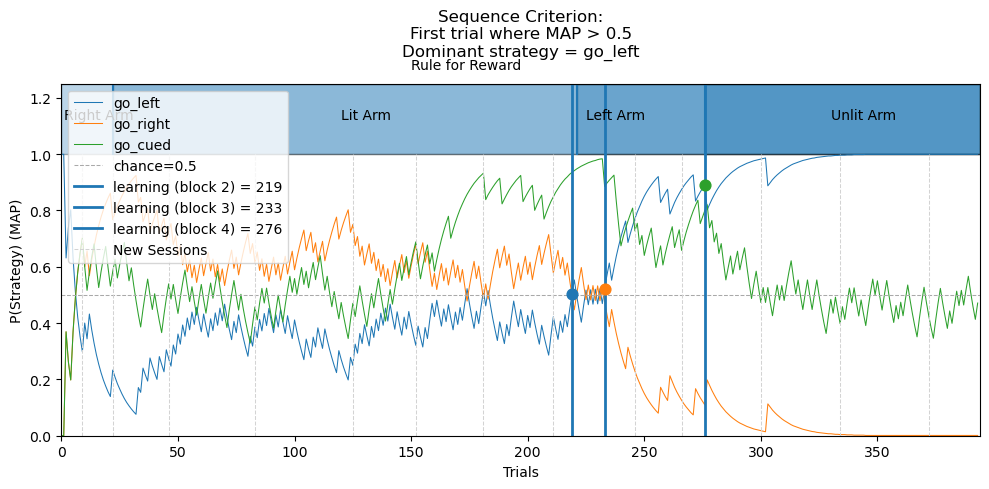

In [9]:
plt.figure(figsize=(10, 5))

for s in rule_strategies:
    plt.plot(Output_collection[s].MAPprobability, linewidth=0.75, label=s)

plt.axhline(y=chance_level, color="darkgrey", linestyle="--", linewidth=0.75, label=f"chance={chance_level}")

# Plot learning trial for each block
for i, lt in enumerate(learning_trials_blocks):
    if lt is None:
        continue
    plt.axvline(lt, linewidth=2, label=f"learning (block {i+1}) = {lt}")
    plt.scatter(lt, MAP[lt], s=60, zorder=5)


plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.title(
    f"Sequence Criterion:\n"
    f"First trial where MAP > 0.5\n"
    f"Dominant strategy = {dominant_rule}",
    pad=20
)
# ----------------------------
# Shade each rule block with a different light color
# ----------------------------

block_starts = [0] + block_boundaries
block_ends = block_boundaries + [len(MAP)]

block_colors = ["#e3f2fd", "#fce4ec", "#e8f5e9", "#fff3e0", "#ede7f6"]

    
plt.axis([0, no_Trials, 0, 1.25])  
plt.legend() 
plt.tight_layout()
plt.show()

# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb